# PCA50: estructura, metadatos y clustering

## Objetivo
Estandarizar la representación PCA50 y evaluar su relación con la estructura de los metadatos antes del modelado.

## Datos de entrada
Se cargan los componentes principales (`eigenvec`/`eigenval`) y metadatos suplementarios.

## Preparación de datos
Se armoniza la clave de identificación, se crea `POOL` y se revisa la integridad del merge con las etiquetas de origen.

## Integración / merge
Se integra PCA50 con metadatos para disponer de una tabla maestra lista para modelado exploratorio y supervisado.

## Análisis exploratorio
Se explora la estructura poblacional con DBSCAN y visualizaciones de PCs, incluyendo composición de clústeres por `POOL`.

## Conclusiones
La representación PCA50 permite contrastar la hipótesis de mayor riqueza dimensional antes de la fase de modelos.

## Próximos pasos
Se conecta con los notebooks de SVR y árboles para contrastar si la mayor dimensionalidad aporta mejora real.


In [1]:
# Imports (ejecuta una vez)
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors


def _resolve_local_file(filename: str, preferred_dirs: tuple[str, ...] = ()) -> Path:
    cwd = Path.cwd().resolve()
    roots = [cwd, *cwd.parents]

    common_dirs = (
        "",
        "nested5x3_unificados",
        "nested5x3_unificados/pheno_data",
        "pheno_data",
        "Old",
    )

    candidates = []
    seen = set()

    for root in roots:
        for rel in (*preferred_dirs, *common_dirs):
            rel_path = Path(rel) if rel else Path()
            candidate = (root / rel_path / filename).resolve()
            key = str(candidate).lower()
            if key not in seen:
                seen.add(key)
                candidates.append(candidate)

    for candidate in candidates:
        if candidate.exists():
            return candidate

    # Fallback: bÃºsqueda recursiva desde el repo (o desde la raÃ­z mÃ¡s cercana)
    repo_root = next((r for r in roots if (r / ".git").exists() or (r / "nested5x3_unificados").exists()), cwd)
    matches = [p.resolve() for p in repo_root.rglob(filename)]

    if matches:
        def score(path: Path) -> tuple[int, int]:
            p = path.as_posix().lower()
            s = 0
            for rel in preferred_dirs:
                if rel and rel.lower() in p:
                    s += 10
            if "nested5x3_unificados" in p:
                s += 3
            if "pheno_data" in p:
                s += 2
            return (-s, len(str(path)))

        matches.sort(key=score)
        return matches[0]

    checked_preview = "\n - ".join(str(c) for c in candidates[:20])
    raise FileNotFoundError(
        f"No se encontrÃ³ '{filename}'. Rutas revisadas (primeras 20):\n - {checked_preview}"
    )


PCA_EIGENVEC_PATH = _resolve_local_file(
    "pca50_mind0.20_g0.10_nomaf_pruned.eigenvec",
    preferred_dirs=("nested5x3_unificados", "Old"),
)
PCA_EIGENVAL_PATH = _resolve_local_file(
    "pca50_mind0.20_g0.10_nomaf_pruned.eigenval",
    preferred_dirs=("nested5x3_unificados", "Old"),
)
META_PATH = _resolve_local_file(
    "giae121_supplemental_file.xlsx",
    preferred_dirs=("nested5x3_unificados/pheno_data", "pheno_data", "nested5x3_unificados", ""),
)
OUTPUT_DIR = PCA_EIGENVEC_PATH.parent




## Datos de entrada

Asegurate de que estos ficheros existen en la carpeta de trabajo:
- `pca50_mind0.20_g0.10_nomaf_pruned.eigenvec`
- `pca50_mind0.20_g0.10_nomaf_pruned.eigenval`


In [2]:
# PCA scores por Muestra
pca = pd.read_csv(
    PCA_EIGENVEC_PATH,
    sep=r"\s+",
    engine="python"
)

# Normalizar columna de identificador
if "#IID" in pca.columns and "IID" not in pca.columns:
    pca = pca.rename(columns={"#IID": "IID"})

pca.head()


,IID,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,...,PC41,PC42,PC43,PC44,PC45,PC46,PC47,PC48,PC49,PC50
0,SAMEA110189749,0.021731,0.060612,0.004454,-0.004955,0.002213,0.015353,0.001085,-0.026854,-0.001630,...,0.002727,-0.004300,-0.002408,-0.018713,0.003555,0.006537,-0.000952,-0.009151,0.000264,0.006097
1,SAMEA110190007,0.021256,0.056980,0.004246,-0.004924,0.002819,0.012161,0.002203,-0.022938,0.000130,...,0.000984,-0.009837,-0.005425,-0.017905,0.006182,0.008501,-0.002650,-0.000363,-0.006461,0.008327
2,SAMEA110189858,0.019452,0.053543,-0.010512,-0.007835,-0.002387,0.002402,0.007720,-0.020817,-0.001749,...,0.002086,-0.011408,-0.001111,-0.006365,0.011992,0.018543,0.005359,0.004413,-0.015867,0.016373
3,SAMEA110189859,0.018701,0.051259,0.003715,-0.006310,-0.005815,0.009391,0.002229,-0.018149,-0.000671,...,0.001973,-0.004879,-0.006615,-0.019357,0.009968,0.013090,0.001174,0.003071,-0.008217,0.010028
4,SAMEA110189802,0.021979,0.054710,0.005621,-0.001745,0.008138,0.017475,-0.004318,-0.016698,0.002093,...,0.000667,0.002509,0.007519,0.008942,-0.003919,-0.010732,0.001435,-0.009126,0.009171,-0.014904


In [3]:
# Varianza explicada por PC (desde eigenval)
eig = np.loadtxt(PCA_EIGENVAL_PATH)
var = eig / eig.sum()
cum = var.cumsum()

pd.DataFrame({
    "PC": [f"PC{i}" for i in range(1, len(eig)+1)],
    "var_explained": var,
    "cum_explained": cum
}).head(50)


,PC,var_explained,cum_explained
0,PC1,0.081092,0.081092
1,PC2,0.051199,0.132291
2,PC3,0.041655,0.173945
3,PC4,0.038655,0.212601
4,PC5,0.035016,0.247617
5,PC6,0.033997,0.281614
6,PC7,0.033198,0.314812
7,PC8,0.031927,0.346739
8,PC9,0.025634,0.372373
9,PC10,0.023935,0.396308


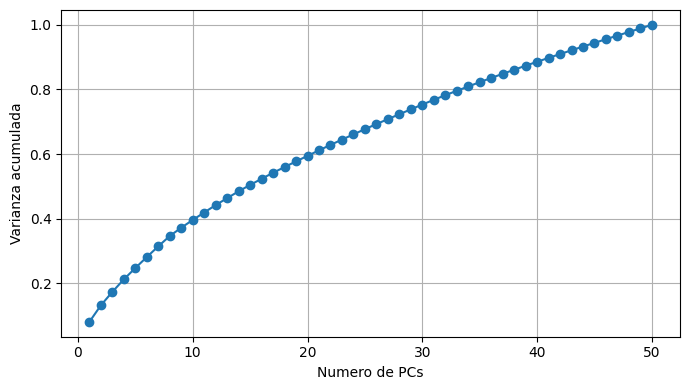

In [4]:
# Curva de varianza acumulada
plt.figure(figsize=(7,4))
plt.plot(range(1, len(cum)+1), cum, marker="o")
plt.xlabel("Numero de PCs")
plt.ylabel("Varianza acumulada")
plt.grid(True)
plt.tight_layout()
plt.show()


## Preparación de datos

El archivo de metadatos del estudio no siempre viene listo para usar.
En este caso, los nombres reales de las columnas estan en la fila 3 (indice 2, base 0), por eso usamos `header=2` al leer el Excel.


In [5]:
meta = pd.read_excel(META_PATH, header=2)

# Quitar columnas basura tipo Unnamed
meta = meta.loc[:, ~meta.columns.astype(str).str.contains(r"^Unnamed", regex=True)]
meta.head()


,genotype,panel,growth_habit,row_type,origin,continent,breeder,release_year,Study,BioSamples ID,genome coverage,mapping rate,genotype name used for BioSamples,Genebank name,doi
0,Abbie,Elite,spring,2-rowed,DEU,Europe,KWS Lochow GmbH,2018.0,PRJEB53924,SAMEA110189749,4.043834,0.980147,Abbie,NaN,NaN
1,Adalina,Elite,winter,6-rowed,AUT,Europe,Saatzucht Donau,2018.0,PRJEB53924,SAMEA110189983,0.853355,0.977618,Adalina,NaN,NaN
2,Advent,Elite,spring,2-rowed,CZE,Europe,Selgen,2009.0,PRJEB53924,SAMEA110190007,2.705384,0.979921,Advent,NaN,NaN
3,AF_Cesar,Elite,spring,2-rowed,CZE,Europe,"Agrotest phyto, s.r.o.",2014.0,PRJEB53924,SAMEA110189858,3.047462,0.978971,AF_Cesar,NaN,NaN
4,AF_Lucius,Elite,spring,2-rowed,CZE,Europe,"Agrotest phyto, s.r.o.",2009.0,PRJEB53924,SAMEA110189859,3.066107,0.978353,AF_Lucius,NaN,NaN


In [6]:
# Renombrar columnas clave y construir POOL
# Ajusta aqui si los nombres difieren en tu Excel

# Buscar columna por nombre exacto o alternativas
cands = {
    "IID": ["BioSamples ID", "BioSample ID", "biosamples id", "sample_id", "Sample_ID", "IID"],
    "GROUP": ["panel", "Panel", "group", "GROUP"],
    "SEASON": ["growth_habit", "growth habit", "season", "SEASON"],
}

# Renombrado con alias compatibles
rename_map = {}
for new_col, options in cands.items():
    found = None
    for opt in options:
        if opt in meta.columns:
            found = opt
            break
    if found is not None:
        rename_map[found] = new_col

meta = meta.rename(columns=rename_map)

# Si no aparecen esas columnas exactas, intenta coincidencia flexible por normalizacion
if not all(k in meta.columns for k in ["IID", "GROUP", "SEASON"]):
    cols_norm = {str(c).strip().lower().replace(" ", "_"): c for c in meta.columns}

    def get_col(candidates):
        for c in candidates:
            k = str(c).strip().lower().replace(" ", "_")
            if k in cols_norm:
                return cols_norm[k]
        for c in candidates:
            ck = str(c).strip().lower().replace(" ", "_")
            for nk, ov in cols_norm.items():
                if ck in nk:
                    return ov
        return None

    missing = []
    if "IID" not in meta.columns:
        col = get_col(["biosamples_id", "biosample_id", "sample_id", "iid"])
        if col is not None:
            meta = meta.rename(columns={col: "IID"})
        else:
            missing.append("IID")
    if "GROUP" not in meta.columns:
        col = get_col(["panel", "group"])
        if col is not None:
            meta = meta.rename(columns={col: "GROUP"})
        else:
            missing.append("GROUP")
    if "SEASON" not in meta.columns:
        col = get_col(["growth_habit", "growth_habit", "season"])
        if col is not None:
            meta = meta.rename(columns={col: "SEASON"})
        else:
            missing.append("SEASON")

if not all(k in meta.columns for k in ["IID", "GROUP", "SEASON"]):
    raise KeyError(f"No se pudieron encontrar columnas clave: {missing}.")

meta["POOL"] = meta["GROUP"].astype(str).str.strip() + "_" + meta["SEASON"].astype(str).str.strip()

meta["POOL"].value_counts()

POOL
PGR_spring      524
PGR_winter      288
Elite_winter    170
Elite_spring    128
Name: count, dtype: int64

## Integración / merge

Este merge es critico: si hay `NaN` en `POOL`, significa que hay IDs de Muestras que no coinciden entre PCA y metadatos.


In [7]:
df = pca.merge(meta[["IID", "POOL"]], on="IID", how="left")

df["POOL"].value_counts(dropna=False)


POOL
PGR_spring      524
PGR_winter      288
Elite_winter    170
Elite_spring    128
Name: count, dtype: int64

In [8]:
df

,IID,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,...,PC42,PC43,PC44,PC45,PC46,PC47,PC48,PC49,PC50,POOL
0,SAMEA110189749,0.021731,0.060612,0.004454,-0.004955,0.002213,0.015353,0.001085,-0.026854,-0.001630,...,-0.004300,-0.002408,-0.018713,0.003555,0.006537,-0.000952,-0.009151,0.000264,0.006097,Elite_spring
1,SAMEA110190007,0.021256,0.056980,0.004246,-0.004924,0.002819,0.012161,0.002203,-0.022938,0.000130,...,-0.009837,-0.005425,-0.017905,0.006182,0.008501,-0.002650,-0.000363,-0.006461,0.008327,Elite_spring
2,SAMEA110189858,0.019452,0.053543,-0.010512,-0.007835,-0.002387,0.002402,0.007720,-0.020817,-0.001749,...,-0.011408,-0.001111,-0.006365,0.011992,0.018543,0.005359,0.004413,-0.015867,0.016373,Elite_spring
3,SAMEA110189859,0.018701,0.051259,0.003715,-0.006310,-0.005815,0.009391,0.002229,-0.018149,-0.000671,...,-0.004879,-0.006615,-0.019357,0.009968,0.013090,0.001174,0.003071,-0.008217,0.010028,Elite_spring
4,SAMEA110189802,0.021979,0.054710,0.005621,-0.001745,0.008138,0.017475,-0.004318,-0.016698,0.002093,...,0.002509,0.007519,0.008942,-0.003919,-0.010732,0.001435,-0.009126,0.009171,-0.014904,Elite_spring
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1105,SAMEA110189426,-0.070153,0.008395,0.029925,0.072656,0.018425,-0.022041,-0.025443,-0.037897,-0.062463,...,-0.025423,-0.026516,0.029038,-0.054857,-0.002077,0.009861,0.006156,0.002966,0.005457,PGR_winter
1106,SAMEA110189428,-0.063170,0.011823,0.019189,0.053068,0.008133,-0.040821,-0.051893,-0.033006,-0.018167,...,0.006306,-0.000666,0.002867,0.022840,-0.007563,0.006612,-0.010004,0.012965,0.007549,PGR_winter
1107,SAMEA110189557,0.008875,-0.026742,-0.024773,0.003318,-0.016614,0.033442,-0.017646,-0.014894,-0.006560,...,-0.007628,-0.022365,0.009529,-0.042366,-0.028767,0.014048,0.008262,-0.034740,-0.027608,PGR_winter
1108,SAMEA110189570,0.014605,-0.031435,-0.003984,-0.003096,0.003602,-0.001217,0.002245,-0.000574,-0.002272,...,-0.019226,-0.033013,0.016520,-0.021527,-0.030874,0.030842,0.001983,-0.035995,-0.006788,PGR_winter


## Análisis exploratorio

DBSCAN se aplica sobre las primeras *k* PCs (por defecto k=12). Se estandarizan las PCs antes de DBSCAN.


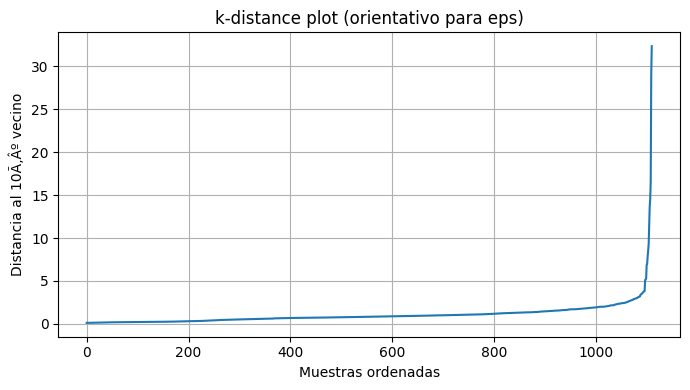

In [9]:
# Parametros
k_pcs = 13
eps = 1.9
min_samples = 10

pc_cols = [f"PC{i}" for i in range(1, k_pcs+1)]
missing_cols = [c for c in ["IID"] + pc_cols if c not in df.columns]
if missing_cols:
    raise ValueError(f"Faltan columnas en el eigenvec: {missing_cols}. Columnas actuales: {list(df.columns)[:15]}")

X = df[pc_cols].to_numpy()
Xz = StandardScaler().fit_transform(X)

# (Opcional) k-distance plot para orientar eps (usa k=min_samples)
nbrs = NearestNeighbors(n_neighbors=min_samples).fit(Xz)
distances, _ = nbrs.kneighbors(Xz)
kdist = np.sort(distances[:, -1])

plt.figure(figsize=(7,4))
plt.plot(kdist)
plt.xlabel("Muestras ordenadas")
plt.ylabel(f"Distancia al {min_samples}Ã‚Âº vecino")
plt.title("k-distance plot (orientativo para eps)")
plt.grid(True)
plt.tight_layout()
plt.show()


In [10]:
# Ejecutar DBSCAN
labels = DBSCAN(eps=eps, min_samples=min_samples).fit_predict(Xz)
df["cluster"] = labels

df["cluster"].value_counts().sort_index()


cluster
-1     47
 0    907
 1     19
 2     82
 3     21
 4     34
Name: count, dtype: int64

In [11]:
# Guardar clusters a CSV (por si quieres reutilizarlos)
df[["IID", "POOL", "cluster"]].to_csv(
    OUTPUT_DIR / f"clusters_dbscan_k{k_pcs}_eps{eps}_min{min_samples}.csv",
    index=False
)


## Análisis exploratorio

1) PCA coloreado por procedencia (POOL)
2) PCA coloreado por cluster DBSCAN
3) Heatmap POOL x cluster


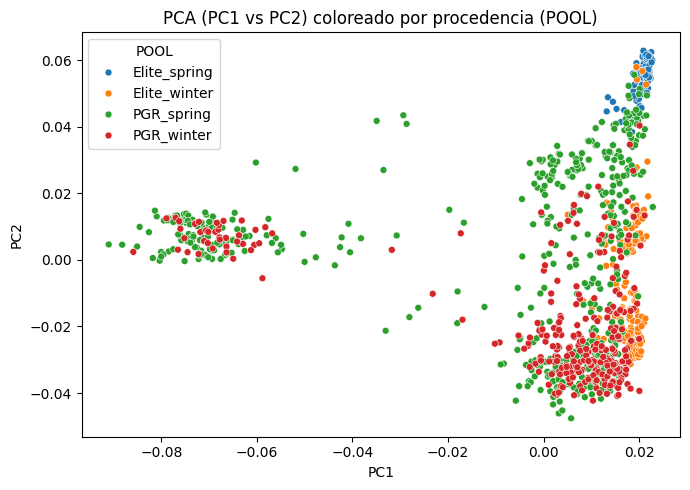

In [12]:
# PCA PC1 vs PC2 coloreado por POOL
plt.figure(figsize=(7,5))
sns.scatterplot(data=df, x="PC1", y="PC2", hue="POOL", s=25)
plt.title("PCA (PC1 vs PC2) coloreado por procedencia (POOL)")
plt.tight_layout()
plt.show()


In [13]:
import pandas as pd
import plotly.express as px

# Base para graficos (sin pisar df original)
df_base = df if "df" in globals() and isinstance(df, pd.DataFrame) else pca.copy()

# Detectar columnas por nombre
# (nombre de muestra, anio, pool) sin tildes

def _find_col(df_input, names):
    cols = {str(c).strip().lower().replace(" ", "_"): c for c in df_input.columns}
    for n in names:
        key = str(n).strip().lower().replace(" ", "_")
        if key in cols:
            return cols[key]
    for c in df_input.columns:
        cl = str(c).strip().lower().replace(" ", "_")
        for n in names:
            k = str(n).strip().lower().replace(" ", "_")
            if k in cl:
                return c
    return None

def _extract_pool_column(df_input):
    if "POOL" in df_input.columns:
        return "POOL"
    if "pool" in df_input.columns:
        return "pool"
    for c in df_input.columns:
        if str(c).strip().lower() == "pool":
            return c
    return None

year_col = _find_col(meta, ["release_year", "year", "anio", "releaseyear"])
if year_col is None:
    year_candidates = [c for c in meta.columns if "year" in str(c).lower()]
    if not year_candidates:
        raise ValueError("No se encontro ninguna columna de ano en meta.")
    year_col = year_candidates[0]

pool_col_meta = _extract_pool_column(meta)
pool_col_base = _extract_pool_column(df_base)

# Merge sin pisar df original; solo traigo anio (y POOL si no existe ya en df_base)
meta_cols = ["IID", year_col]
if pool_col_meta is not None and pool_col_base is None:
    meta_cols.append(pool_col_meta)

# Merge necesario para anio y pool si falta en base
df_plot_elite = df_base.merge(meta[meta_cols].copy(), on="IID", how="left") if (
    year_col not in df_base.columns or pool_col_base is None
) else df_base.copy()

# normalizar nombre de anio
if year_col in df_plot_elite.columns:
    df_plot_elite = df_plot_elite.rename(columns={year_col: "release_year"})
else:
    df_plot_elite["release_year"] = pd.NA

# asegurar columna POOL final con nombre final
if "POOL" not in df_plot_elite.columns:
    if pool_col_base is not None and pool_col_base in df_plot_elite.columns:
        if pool_col_base != "POOL":
            df_plot_elite = df_plot_elite.rename(columns={pool_col_base: "POOL"})
    elif "POOL_y" in df_plot_elite.columns:
        df_plot_elite["POOL"] = df_plot_elite["POOL_y"]
    elif "POOL_x" in df_plot_elite.columns:
        df_plot_elite["POOL"] = df_plot_elite["POOL_x"]
    elif pool_col_meta is not None and pool_col_meta in df_plot_elite.columns:
        df_plot_elite = df_plot_elite.rename(columns={pool_col_meta: "POOL"})

if "release_year" not in df_plot_elite.columns:
    df_plot_elite["release_year"] = pd.NA
if "POOL" not in df_plot_elite.columns:
    df_plot_elite["POOL"] = pd.NA

df_plot_elite["release_year"] = pd.to_numeric(df_plot_elite["release_year"], errors="coerce").astype("Int64")

# Filtrar solo material Elite (si no existe POOL, devuelve vacio)
if "POOL" in df_plot_elite.columns:
    df_elite = df_plot_elite[df_plot_elite["POOL"].astype(str).str.startswith("Elite", na=False)].copy()
else:
    df_elite = df_plot_elite.iloc[0:0].copy()

# Grafico interactivo PC1 vs PC2 con ano al hover
fig = px.scatter(
    df_elite,
    x="PC1",
    y="PC2",
    color="POOL",
    hover_data={
        "IID": True,
        "release_year": True,
        "POOL": True,
        "PC1": False,
        "PC2": False,
    },
    title="PCA PC1 vs PC2 (solo material Elite) - hover con aÃ±o de lanzamiento",
    height=550,
)
fig.update_traces(marker=dict(size=7))
fig.show()


In [14]:
import pandas as pd
import plotly.express as px

# Base para graficos (sin pisar df original)
df_base = df if "df" in globals() and isinstance(df, pd.DataFrame) else pca.copy()

# ---- helpers simples para detectar columnas por alias ----
def _find_col(df_input, names):
    cols_norm = {str(c).strip().lower().replace(" ", "_"): c for c in df_input.columns}
    for opt in names:
        k = str(opt).strip().lower().replace(" ", "_")
        if k in cols_norm:
            return cols_norm[k]
    for c in df_input.columns:
        cl = str(c).strip().lower().replace(" ", "_")
        for opt in names:
            k = str(opt).strip().lower().replace(" ", "_")
            if k in cl:
                return c
    return None

def _extract_pool_column(df_input):
    if "POOL" in df_input.columns:
        return "POOL"
    if "pool" in df_input.columns:
        return "pool"
    for c in df_input.columns:
        if str(c).strip().lower() == "pool":
            return c
    return None

def _add_pool(df_plot):
    if "POOL" in df_plot.columns:
        return df_plot
    if "POOL_x" in df_plot.columns:
        df_plot["POOL"] = df_plot["POOL_x"]
        return df_plot
    if "POOL_y" in df_plot.columns:
        df_plot["POOL"] = df_plot["POOL_y"]
    return df_plot

year_col = _find_col(meta, ["release_year", "year", "anio"])
if year_col is None:
    raise ValueError("No se encontro ninguna columna de ano en meta.")

cont_col = _find_col(meta, ["continent", "origin", "continente", "region"])
if cont_col is None:
    raise ValueError("No se encontro columna de continente u origen en meta.")

pool_col_base = _extract_pool_column(df_base)
pool_col_meta = _extract_pool_column(meta)

meta_cols = ["IID", year_col, cont_col]
if pool_col_base is None and pool_col_meta is not None:
    meta_cols.append(pool_col_meta)

# Merge sin destruir df base
if any(c not in df_base.columns for c in [year_col, cont_col]):
    df_plot = df_base.merge(meta[meta_cols].copy(), on="IID", how="left")
else:
    df_plot = df_base.copy()

# normalizar nombres
if year_col in df_plot.columns:
    df_plot = df_plot.rename(columns={year_col: "release_year"})
if cont_col in df_plot.columns:
    df_plot = df_plot.rename(columns={cont_col: "continent"})

if "POOL" not in df_plot.columns and pool_col_base is not None and pool_col_base in df_plot.columns:
    df_plot = df_plot.rename(columns={pool_col_base: "POOL"})

df_plot = _add_pool(df_plot)
if "POOL" not in df_plot.columns:
    df_plot["POOL"] = pd.NA

if "release_year" not in df_plot.columns:
    df_plot["release_year"] = pd.NA

df_plot["release_year"] = pd.to_numeric(df_plot["release_year"], errors="coerce").astype("Int64")

# Grafico interactivo (todo el material)
fig = px.scatter(
    df_plot,
    x="PC1",
    y="PC2",
    color="continent",
    hover_data={
        "IID": True,
        "release_year": True,
        "continent": True,
        "POOL": True,
        "PC1": False,
        "PC2": False,
    },
    title="PCA PC1 vs PC2 (coloreado por continente) - tooltip con ano",
    height=550,
)
fig.update_traces(marker=dict(size=7))
fig.show()


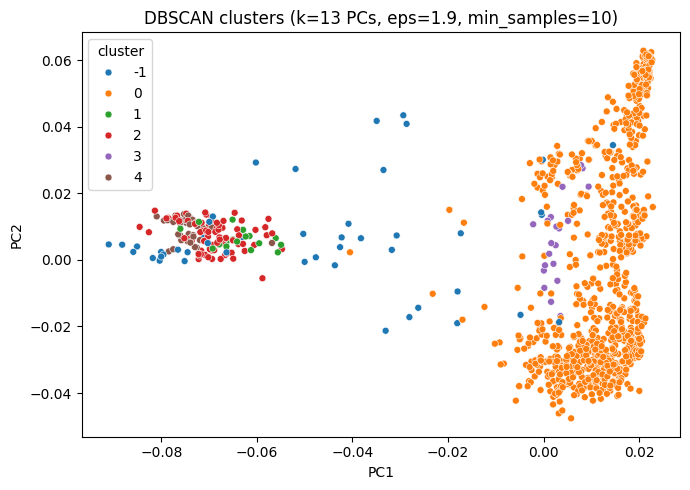

In [15]:
# PCA PC1 vs PC2 coloreado por cluster DBSCAN
plt.figure(figsize=(7,5))
sns.scatterplot(data=df, x="PC1", y="PC2", hue="cluster", s=25, palette="tab10")
plt.title(f"DBSCAN clusters (k={k_pcs} PCs, eps={eps}, min_samples={min_samples})")
plt.tight_layout()
plt.show()



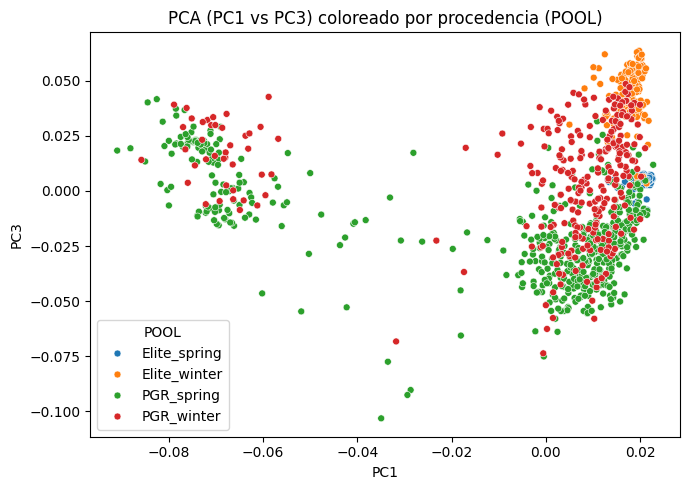

In [16]:
# PCA PC1 vs PC3 coloreado por POOL
plt.figure(figsize=(7,5))
sns.scatterplot(data=df, x="PC1", y="PC3", hue="POOL", s=25)
plt.title("PCA (PC1 vs PC3) coloreado por procedencia (POOL)")
plt.tight_layout()
plt.show()


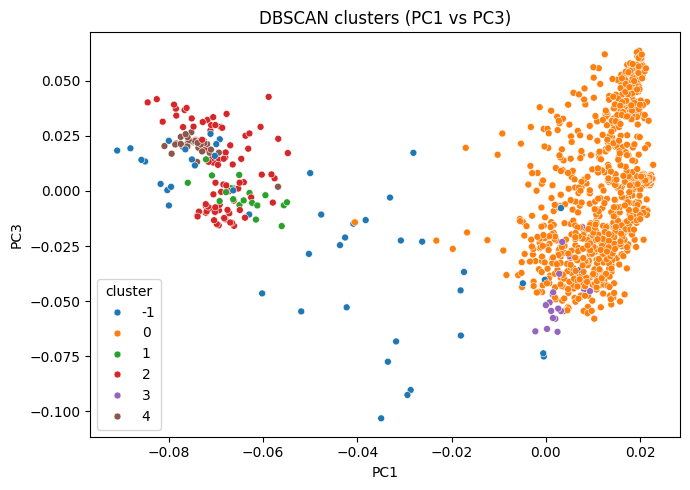

In [17]:
# Opcional: PC1 vs PC3 por cluster
plt.figure(figsize=(7,5))
sns.scatterplot(data=df, x="PC1", y="PC3", hue="cluster", s=25, palette="tab10")
plt.title("DBSCAN clusters (PC1 vs PC3)")
plt.tight_layout()
plt.show()


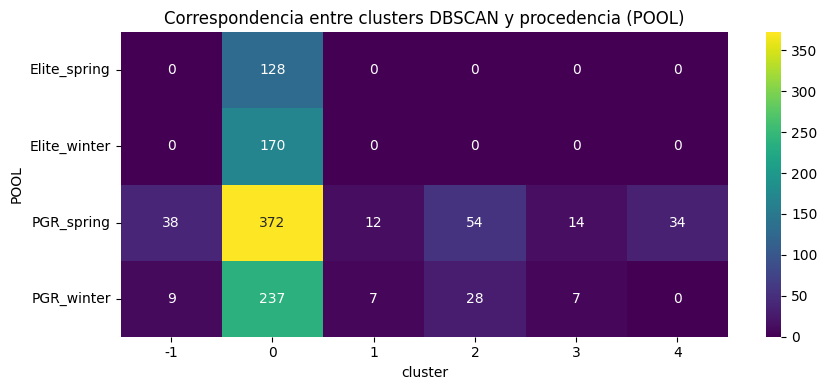

cluster,-1,0,1,2,3,4
POOL,,,,,,
Elite_spring,0,128,0,0,0,0
Elite_winter,0,170,0,0,0,0
PGR_spring,38,372,12,54,14,34
PGR_winter,9,237,7,28,7,0


In [18]:
# Heatmap: procedencia vs cluster
ct = pd.crosstab(df["POOL"], df["cluster"])

plt.figure(figsize=(9,4))
sns.heatmap(ct, annot=True, fmt="d", cmap="viridis")
plt.title("Correspondencia entre clusters DBSCAN y procedencia (POOL)")
plt.tight_layout()
plt.show()

ct


In [19]:
## kNN
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score
import numpy as np


In [20]:
pc_cols = [c for c in df.columns if c.startswith("PC")][:12]
X = df[pc_cols].values
y = df["POOL"].values

Xs = StandardScaler().fit_transform(X)

knn = KNeighborsClassifier(n_neighbors=3)

scores = cross_val_score(
    knn,
    Xs,
    y,
    cv=5
)

print(f"Accuracy media (5-fold CV): {scores.mean():.3f}")
print(f"Desviacion estandar: {scores.std():.3f}")


Accuracy media (5-fold CV): 0.833
Desviacion estandar: 0.016


In [21]:
knn.fit(Xs, y)
df["knn_pred"] = knn.predict(Xs)


In [22]:
import pandas as pd

conf = pd.crosstab(
    df["POOL"],
    df["knn_pred"],
    rownames=["Real"],
    colnames=["Predicho"]
)

conf


Predicho,Elite_spring,Elite_winter,PGR_spring,PGR_winter
Real,,,,
Elite_spring,126,1,1,0
Elite_winter,4,166,0,0
PGR_spring,4,0,482,38
PGR_winter,0,5,52,231


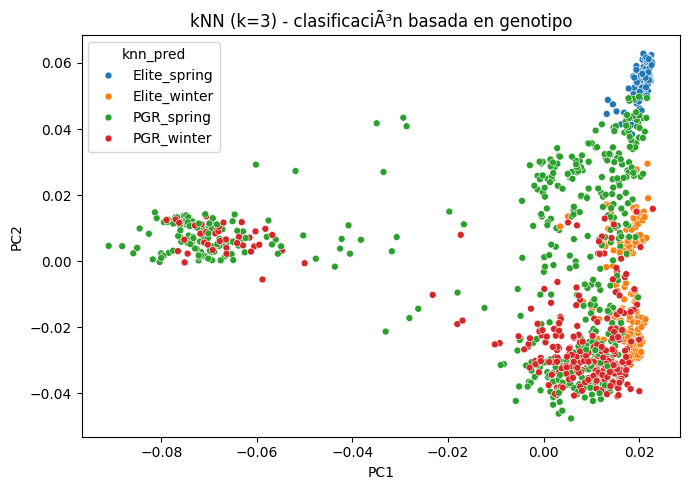

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7,5))
sns.scatterplot(
    data=df,
    x="PC1",
    y="PC2",
    hue="knn_pred",
    s=25
)
plt.title("kNN (k=3) - clasificación basada en genotipo")
plt.tight_layout()
plt.show()


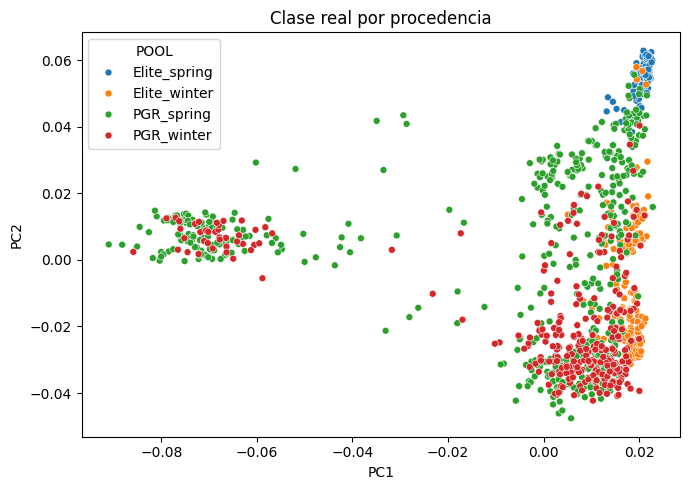

In [24]:
plt.figure(figsize=(7,5))
sns.scatterplot(
    data=df,
    x="PC1",
    y="PC2",
    hue="POOL",
    s=25
)
plt.title("Clase real por procedencia")
plt.tight_layout()
plt.show()


In [25]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import SpectralClustering

pc_cols = [c for c in df.columns if c.startswith("PC")][:12]
X = df[pc_cols].values

Xs = StandardScaler().fit_transform(X)


In [26]:
spec = SpectralClustering(
    n_clusters=4,
    affinity="nearest_neighbors",
    n_neighbors=10,
    assign_labels="kmeans",
    random_state=42
)

df["spectral_cluster"] = spec.fit_predict(Xs)

df["spectral_cluster"].value_counts()


c:\Users\Reyes\AppData\Local\Programs\Python\Python311\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning:

Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.

  File "c:\Users\Reyes\AppData\Local\Programs\Python\Python311\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\Users\Reyes\AppData\Local\Programs\Python\Python311\Lib\subprocess.py", line 546, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Reyes\AppData\Local\Programs\Python\Python311\Lib\subprocess.py", line 1022, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "c:\Users\

spectral_cluster
3    519
1    292
0    160
2    139
Name: count, dtype: int64

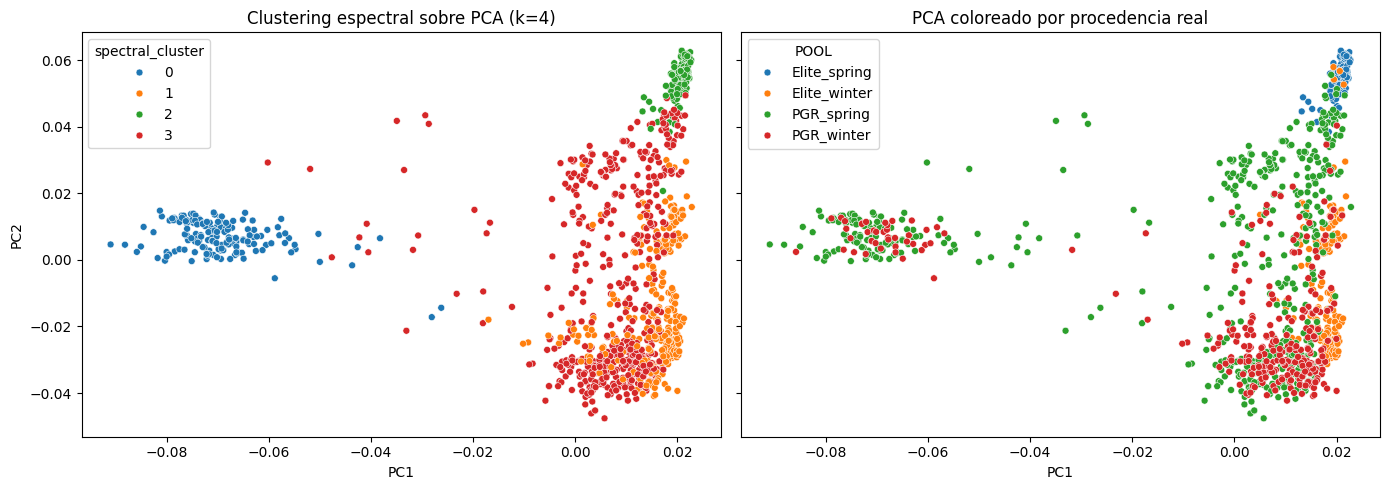

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True, sharey=True)

# --- Izquierda: clustering espectral ---
sns.scatterplot(
    data=df,
    x="PC1",
    y="PC2",
    hue="spectral_cluster",
    palette="tab10",
    s=25,
    ax=axes[0]
)
axes[0].set_title("Clustering espectral sobre PCA (k=4)")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")

# --- Derecha: procedencia real ---
sns.scatterplot(
    data=df,
    x="PC1",
    y="PC2",
    hue="POOL",
    s=25,
    ax=axes[1]
)
axes[1].set_title("PCA coloreado por procedencia real")
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")

plt.tight_layout()
plt.show()



In [28]:
import pandas as pd

ct_spec = pd.crosstab(df["POOL"], df["spectral_cluster"])
ct_spec


spectral_cluster,0,1,2,3
POOL,,,,
Elite_spring,0,1,125,2
Elite_winter,0,166,4,0
PGR_spring,120,15,10,379
PGR_winter,40,110,0,138


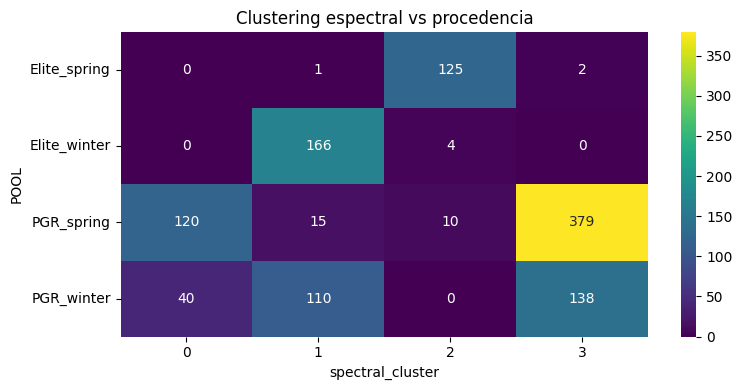

In [29]:
plt.figure(figsize=(8,4))
sns.heatmap(ct_spec, annot=True, fmt="d", cmap="viridis")
plt.title("Clustering espectral vs procedencia")
plt.tight_layout()
plt.show()

